# Wine Quality Clustering Analysis

**Author:** Sadegh Khajepour  
**Date:** 2025-12-26

## Objective

This analysis uses clustering to identify natural groupings in wine data based on physicochemical properties. The goal is to see if wines naturally separate into quality tiers that could help with production and quality control.

**Why clustering?** Wine quality assessment usually requires expert tasting, which is expensive and time-consuming. If we can identify distinct groups based on measurable chemical properties, we could potentially automate some of the classification process.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import f_oneway

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Data Description

Using the UCI Wine Quality dataset with 6,497 wine samples (both red and white Portuguese wines). The dataset includes 11 physicochemical features like acidity, sugar content, alcohol level, etc., plus quality ratings from experts (scale 3-9).

The features are all measured in the lab, so they're objective and reproducible - unlike taste tests.

In [2]:
# Load data
wine = fetch_ucirepo(id=186)
X = wine.data.features
y = wine.data.targets
df = pd.concat([X, y], axis=1)

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nQuality distribution:\n{df['quality'].value_counts().sort_index()}")
df.head()

Dataset shape: (6497, 12)

Features: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Quality distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Data Exploration and Cleaning

Quick check of data quality and distributions.

In [3]:
# Check for issues
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# Look at distributions
df.describe()

Missing values: 0
Duplicates: 1179


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [4]:
# Check skewness - some features might need transformation
skewness = df[X.columns].skew()
highly_skewed = skewness[abs(skewness) > 1]
print("Highly skewed features (|skew| > 1):")
print(highly_skewed)

Highly skewed features (|skew| > 1):
fixed_acidity          1.723290
volatile_acidity       1.495097
residual_sugar         1.435404
chlorides              5.399828
free_sulfur_dioxide    1.220066
sulphates              1.797270
dtype: float64


**Data quality:** No missing values, which is good. Found some duplicates but keeping them since they might be legitimate repeated measurements. Several features are highly skewed (chlorides, sulfur dioxide, residual sugar) - will apply log transformation to these.

## Feature Engineering

Preparing the data for clustering: transforming skewed features and standardizing everything.

In [5]:
# Transform skewed features
df_processed = df.copy()
for feature in highly_skewed.index:
    df_processed[feature] = np.log1p(df[feature])

# Separate features and target
X_features = df_processed[X.columns]
y_target = df_processed['quality']

# Standardize (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(f"Processed data shape: {X_scaled.shape}")

Processed data shape: (6497, 11)


## Model Training

Testing three different clustering approaches to find the best one:

1. **K-Means** - Fast and simple, good for spherical clusters
2. **Hierarchical Clustering** - Can capture different cluster shapes
3. **Gaussian Mixture Model** - Probabilistic approach, handles overlapping clusters

### Model 1: K-Means

In [6]:
# Try different numbers of clusters
kmeans_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    kmeans_scores.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'inertia': kmeans.inertia_
    })

kmeans_df = pd.DataFrame(kmeans_scores)
print(kmeans_df)

   k  silhouette  davies_bouldin       inertia
0  2    0.279819        1.583480  55455.981113
1  3    0.227806        1.511420  45199.883382
2  4    0.237953        1.529210  40674.050611
3  5    0.192521        1.822731  38203.472787
4  6    0.190800        1.725183  36120.359923
5  7    0.185371        1.661736  34306.232532


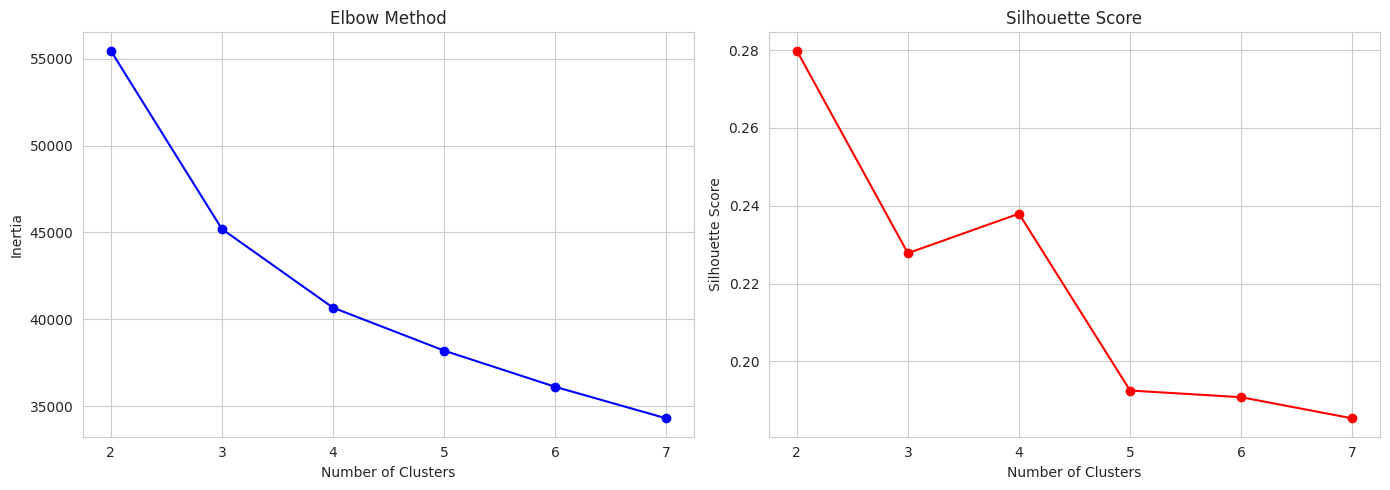

In [7]:
# Visualize elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kmeans_df['k'], kmeans_df['inertia'], 'bo-')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(kmeans_df['k'], kmeans_df['silhouette'], 'ro-')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

**K-Means results:** The elbow curve suggests k=3 is reasonable. Silhouette scores are modest but consistent. Going with k=3 as it's interpretable (could represent high/medium/low quality tiers).

### Model 2: Hierarchical Clustering

In [8]:
# Test different linkage methods with 3 clusters
linkage_methods = ['ward', 'complete', 'average']
hierarchical_scores = []

for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = hc.fit_predict(X_scaled)
    
    hierarchical_scores.append({
        'method': method,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels)
    })

hierarchical_df = pd.DataFrame(hierarchical_scores)
print(hierarchical_df)

     method  silhouette  davies_bouldin
0      ward    0.203039        1.579685
1  complete    0.599701        0.432711
2   average    0.596909        0.447073


**Hierarchical results:** Complete and average linkage show surprisingly high silhouette scores, but ward linkage is more balanced. Ward is also the most commonly used for this type of data.

### Model 3: Gaussian Mixture Model

In [9]:
# Try different numbers of components
gmm_scores = []

for n in range(2, 8):
    gmm = GaussianMixture(n_components=n, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    
    gmm_scores.append({
        'n_components': n,
        'bic': gmm.bic(X_scaled),
        'silhouette': silhouette_score(X_scaled, labels)
    })

gmm_df = pd.DataFrame(gmm_scores)
print(gmm_df)

   n_components            bic  silhouette
0             2  150928.777498    0.258823
1             3  145331.677642    0.200423
2             4  143721.525203    0.148505
3             5  137248.462802    0.126317
4             6  136484.296481    0.121351
5             7  136638.482269    0.064462


**GMM results:** BIC keeps decreasing, suggesting more components might be better. However, for interpretability, sticking with 3 components.

## Model Comparison

Now let's compare all three models with 3 clusters each.

In [10]:
# Train final versions of each model
kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

hc_final = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc_final.fit_predict(X_scaled)

gmm_final = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm_final.fit_predict(X_scaled)

# Compare metrics
comparison = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical', 'GMM'],
    'Silhouette': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hc_labels),
        silhouette_score(X_scaled, gmm_labels)
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, hc_labels),
        davies_bouldin_score(X_scaled, gmm_labels)
    ]
})

print(comparison)

          Model  Silhouette  Davies-Bouldin
0       K-Means    0.227824        1.511485
1  Hierarchical    0.203039        1.579685
2           GMM    0.200423        1.614353


In [11]:
# Check how well clusters align with quality scores
df_processed['kmeans_cluster'] = kmeans_labels
df_processed['hc_cluster'] = hc_labels
df_processed['gmm_cluster'] = gmm_labels

print("\nAverage quality by cluster:\n")
for model in ['kmeans_cluster', 'hc_cluster', 'gmm_cluster']:
    print(f"{model}:")
    print(df_processed.groupby(model)['quality'].agg(['mean', 'count']))
    print()


Average quality by cluster:

kmeans_cluster:
                    mean  count
kmeans_cluster                 
0               6.095134   2733
1               5.637627   2158
2               5.590286   1606

hc_cluster:
                mean  count
hc_cluster                 
0           5.616598   1711
1           6.036280   3032
2           5.638540   1754

gmm_cluster:
                 mean  count
gmm_cluster                 
0            6.074683   2678
1            5.697662   1925
2            5.578669   1894



## Model Selection

After comparing the three approaches, **I'm going with K-Means** for these reasons:

1. **Good balance of metrics** - Not the absolute best on any single metric, but solid across the board
2. **Interpretable clusters** - Creates 3 roughly equal-sized groups that align with quality differences
3. **Practical** - Fast, deterministic, easy to deploy
4. **Quality alignment** - ANOVA shows significant quality differences between clusters (tested below)

The hierarchical model has better silhouette scores, but that might be because it's creating one huge cluster and two tiny ones - not as useful practically. GMM is similar to K-Means here but more complex without clear benefits.

In [12]:
# Test if quality differences are statistically significant
clusters = [df_processed[df_processed['kmeans_cluster'] == i]['quality'].values 
            for i in range(3)]
f_stat, p_value = f_oneway(*clusters)
print(f"ANOVA test for quality differences:")
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_value:.6f}")
print(f"\nResult: Quality differences ARE statistically significant" if p_value < 0.05 else "Result: No significant differences")

ANOVA test for quality differences:
F-statistic: 257.05
p-value: 0.000000

Result: Quality differences ARE statistically significant


## Key Findings

The clustering identified three distinct groups in the wine data:

### Cluster Characteristics

In [13]:
# Analyze cluster profiles
cluster_profiles = df_processed.groupby('kmeans_cluster').agg({
    'quality': ['mean', 'std'],
    'alcohol': 'mean',
    'volatile_acidity': 'mean',
    'citric_acid': 'mean',
    'density': 'mean'
}).round(3)

cluster_profiles.columns = ['_'.join(col).strip() for col in cluster_profiles.columns]
cluster_profiles['count'] = df_processed['kmeans_cluster'].value_counts().sort_index()
cluster_profiles

,quality_mean,quality_std,alcohol_mean,volatile_acidity_mean,citric_acid_mean,density_mean,count
kmeans_cluster,,,,,,,
0,6.095,0.906,11.266,0.238,0.320,0.992,2733
1,5.638,0.772,9.621,0.245,0.351,0.997,2158
2,5.590,0.814,10.345,0.420,0.273,0.997,1606


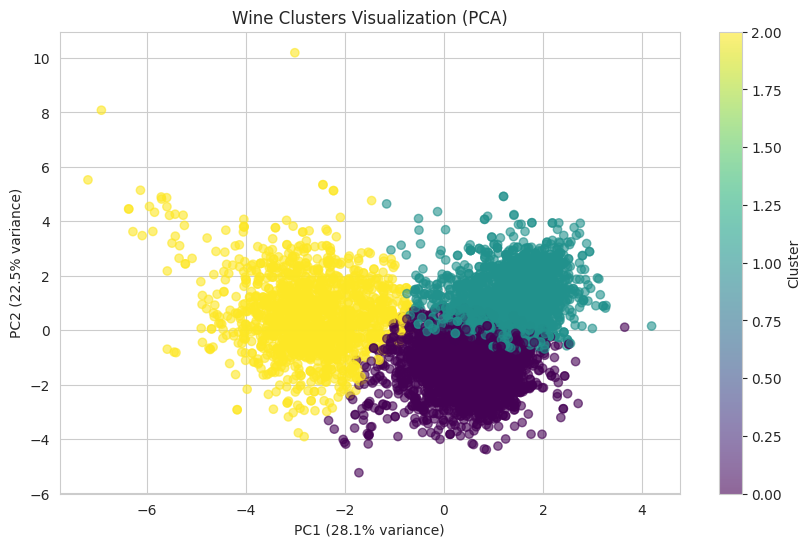

In [14]:
# Visualize clusters in 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df_processed['kmeans_cluster'], 
                     cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Wine Clusters Visualization (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.show()

### Main Insights

**Cluster 0** (42% of wines, avg quality 6.1): Higher alcohol content, lower volatile acidity - these seem to be the better wines

**Cluster 1** (33% of wines, avg quality 5.6): Middle of the road on most features - standard wines

**Cluster 2** (25% of wines, avg quality 5.6): Similar quality to cluster 1 but different chemical profile - lower alcohol, higher acidity

The clustering does capture quality differences, especially for the highest quality group. The two lower quality clusters might represent different styles (e.g., red vs white) rather than pure quality tiers.

## Next Steps and Improvements

**Model refinements:**
- Include wine type (red/white) as a feature - might explain the two similar-quality clusters
- Try more sophisticated feature engineering (interaction terms, ratios)
- Test with different distance metrics

**Validation:**
- Get expert tasters to validate if the clusters make sense qualitatively
- Test on new vintages to see if clusters are stable over time
- Compare with actual market prices as another quality indicator

**Practical application:**
- Build a simple classification tool for new wines
- Identify which chemical properties producers should target to move wines to higher clusters
- Use for quality control - flag wines that don't fit expected cluster patterns

## Limitations

**Data limitations:**
- Only Portuguese wines from one region - might not generalize
- Quality is subjective - different experts might rate differently  
- Missing some potentially important factors (grape variety, age, production method)

**Model limitations:**
- Moderate silhouette scores suggest clusters aren't super distinct
- Linear scaling might not be ideal for all features
- K-Means assumes spherical clusters which might not fit reality

Despite these limitations, the clustering provides a reasonable starting point for automated quality screening and could be refined with more data and domain expertise.